In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [4]:
# --- 1. Data Exploration ---
train_df = pd.read_csv('Titanic_train.csv')
test_df = pd.read_csv('Titanic_test.csv')


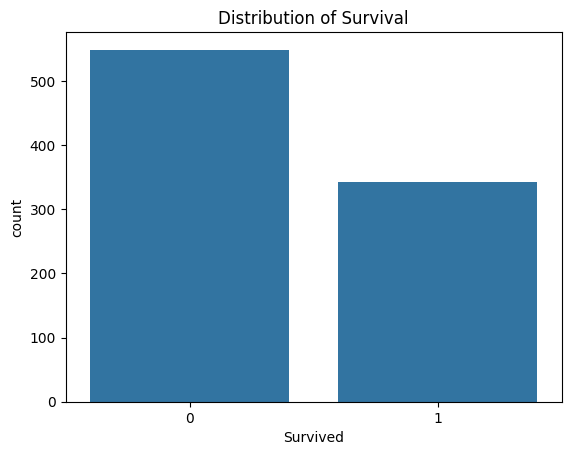

In [5]:
# Visualizing target distribution
sns.countplot(x='Survived', data=train_df)
plt.title('Distribution of Survival')
plt.show()

In [6]:
# Filling missing values
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

In [7]:
# Encoding categorical variables
le = LabelEncoder()
train_df['Sex'] = le.fit_transform(train_df['Sex'])
train_df['Embarked'] = le.fit_transform(train_df['Embarked'])

In [8]:
# Dropping non-essential columns
X = train_df.drop(['Survived', 'Name', 'Ticket', 'Cabin', 'PassengerId'], axis=1)
y = train_df['Survived']

In [9]:
# Split for evaluation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
# XGBoost Model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [11]:
# LightGBM Model
lgbm_model = LGBMClassifier()
lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000102 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 194
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier()

In [12]:
# --- 5. Model Evaluation ---
def evaluate_model(model, X_v, y_v):
    preds = model.predict(X_v)
    probs = model.predict_proba(X_v)[:, 1]
    return {
        'Accuracy': accuracy_score(y_v, preds),
        'Precision': precision_score(y_v, preds),
        'Recall': recall_score(y_v, preds),
        'F1-Score': f1_score(y_v, preds),
        'ROC-AUC': roc_auc_score(y_v, probs)
    }

xgb_results = evaluate_model(xgb_model, X_val, y_val)
lgbm_results = evaluate_model(lgbm_model, X_val, y_val)

print("XGBoost Results:", xgb_results)
print("LightGBM Results:", lgbm_results)

XGBoost Results: {'Accuracy': 0.7988826815642458, 'Precision': 0.7567567567567568, 'Recall': 0.7567567567567568, 'F1-Score': 0.7567567567567568, 'ROC-AUC': np.float64(0.8624195624195623)}
LightGBM Results: {'Accuracy': 0.8212290502793296, 'Precision': 0.7837837837837838, 'Recall': 0.7837837837837838, 'F1-Score': 0.7837837837837838, 'ROC-AUC': np.float64(0.8815958815958816)}
